## Lab 3 – Word2Vec

### 실습 개념 흐름 (Lab Conceptual Flow)

- 샘플 문장 (Sample Sentences)
- 토큰화 (Tokenization)
- 어휘 사전 → 단어 ID (Vocabulary → word IDs)
- 문맥 윈도우 (Context Window)
- 학습 쌍 생성 (Training Pair Generation)
- PyTorch Dataset / DataLoader
- 임베딩 레이어 (Embedding Layer)
- Skip-gram 또는 CBOW 네트워크
- 모델 + 배치를 GPU로 이동
- GPU 학습
- 단어 임베딩 추출
- GPU 코사인 유사도
- 최근접 단어 (Nearest Words)
- 벡터 연산 (Vector Arithmetic)
- PCA 시각화
- 윈도우 크기 실험 (Window-size Experiment)
- Word2Vec의 한계

### 패키지 설치

- 기존 llm_lab01 환경에서 다음 명령어로 설치한다.

    ```bash
    python -m pip install gensim scikit-learn matplotlib
    ```

- `gensim`: 비지도 의미 모델링(Latent Semantic Analysis, Latent Dirichlet Allocation 등), 단어 임베딩(Word2Vec, FastText), 효율적인 유사도 질의. (이번에는 사용하지 않는다)
- `matplotlib`: 선 그래프, 산점도, 히스토그램, 막대 그래프, 오차 도표 등 2D 차트와 그래프 생성.

### GPU 설정

- 기존 llm_lab01 환경에서 다음 명령어로 설치한다.

In [4]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Device: cpu


### 작은 말뭉치 준비 (Prepare a Small Corpus)

In [6]:
sentences = [
    "king is a royal man",
    "queen is a royal woman",
    "king rules the kingdom",
    "queen rules the kingdom",
    "king lives in the palace",
    "queen lives in the palace",
    "prince is a young man",
    "princess is a young woman",
    "prince lives in the palace",
    "princess lives in the palace",
    "man is a male person",
    "woman is a female person",
    "boy is a young male",
    "girl is a young female",
    "dog is an animal",
    "cat is an animal",
    "dog is a pet",
    "cat is a pet",
    "puppy is a young dog",
    "kitten is a young cat",
    "apple is a fruit",
    "banana is a fruit",
    "orange is a fruit",
    "apple is sweet",
    "banana is sweet",
    "orange is sweet",
    "car is a vehicle",
    "bus is a vehicle",
    "truck is a vehicle",
    "car moves on road",
    "bus moves on road",
    "truck moves on road",
]

### 토큰화 (Tokenize)

In [7]:
corpus = []

for sentence in sentences:
    tokens = sentence.lower().split()
    corpus.append(tokens)

for tokens in corpus[:5]:
    print(tokens)

['king', 'is', 'a', 'royal', 'man']
['queen', 'is', 'a', 'royal', 'woman']
['king', 'rules', 'the', 'kingdom']
['queen', 'rules', 'the', 'kingdom']
['king', 'lives', 'in', 'the', 'palace']


### 어휘 사전 구축 (Build Vocabulary)

- Word2Vec 신경망은 문자열을 직접 입력받지 않는다. king → 0, queen → 1, dog → 2, ....

In [8]:
words = []
for sentence in corpus:
    words.extend(sentence)

vocab = sorted(set(words))
word_to_id = {
    word: i
    for i, word in enumerate(vocab)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print(word_to_id)

Vocabulary size: 40
{'a': 0, 'an': 1, 'animal': 2, 'apple': 3, 'banana': 4, 'boy': 5, 'bus': 6, 'car': 7, 'cat': 8, 'dog': 9, 'female': 10, 'fruit': 11, 'girl': 12, 'in': 13, 'is': 14, 'king': 15, 'kingdom': 16, 'kitten': 17, 'lives': 18, 'male': 19, 'man': 20, 'moves': 21, 'on': 22, 'orange': 23, 'palace': 24, 'person': 25, 'pet': 26, 'prince': 27, 'princess': 28, 'puppy': 29, 'queen': 30, 'road': 31, 'royal': 32, 'rules': 33, 'sweet': 34, 'the': 35, 'truck': 36, 'vehicle': 37, 'woman': 38, 'young': 39}


- `.extend()`: 컬렉션을 풀어서(unpack) 그 안의 각 요소가 원래 리스트의 평평한(flat) 요소가 되도록 한다.
- `set(words)`: 중복 항목을 모두 제거하고 고유한 요소만 남긴다.
- `sorted(...)`: 고유 항목들을 알파벳 순으로 정렬하고, set을 다시 리스트로 변환한다.

### Skip-gram 학습 쌍 생성 (Generate Skip-gram Training Pair)

- "king is a royal man"에 대해 window_size = 2로 (royal, is), (royal, a), (royal, man) 같은 중심어-문맥어(center-context) 쌍을 만든다.

In [9]:
def create_skipgram_pairs(corpus,
                          window=2):
    pairs = []
    for sentence in corpus:
        for i in range(len(sentence)):
            center_word = sentence[i]
            start = max(0, i - window)
            end = min(
                len(sentence),
                i + window + 1
            )
            for j in range(start, end):
                if i == j:
                    continue
                context_word = sentence[j]
                center_id = word_to_id[
                    center_word
                ]
                context_id = word_to_id[
                    context_word
                ]
                pairs.append(
                    (center_id, context_id)
                )
    return pairs

- 생성하고 확인한다.

In [10]:
pairs = create_skipgram_pairs(
    corpus,
    window=2
)

print("No of training pairs:", len(pairs))

for center_id, context_id in pairs[:20]:

    print(
        id_to_word[center_id],
        "->",
        id_to_word[context_id]
    )

No of training pairs: 364
king -> is
king -> a
is -> king
is -> a
is -> royal
a -> king
a -> is
a -> royal
a -> man
royal -> is
royal -> a
royal -> man
man -> a
man -> royal
queen -> is
queen -> a
is -> queen
is -> a
is -> royal
a -> queen


### 학습 데이터를 텐서로 변환 (Convert Training Data to Tensors)

- 튜플 데이터 타입이 필요하다.

In [11]:
center_words = torch.tensor(
    [pair[0] for pair in pairs],
    dtype=torch.long
)

context_words = torch.tensor(
    [pair[1] for pair in pairs],
    dtype=torch.long
)

print(center_words.shape)
print(context_words.shape)

torch.Size([364])
torch.Size([364])


### DataLoader 사용

- 분리된 입력 텐서들을 하나의 데이터셋으로 결합한다.

In [12]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

dataset = TensorDataset(
    center_words,
    context_words
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

- `DataLoader(...)`: 학습 루프 동안 배치 처리와 데이터 로딩을 자동으로 처리하는 효율적인 반복자(iterator)를 생성한다.
- `batch_size=64`: 병렬 처리를 위해 64개의 데이터 쌍을 하나의 배치로 묶는다.
- `shuffle=True`: 매 epoch 시작 시 데이터셋 순서를 무작위로 섞어, 모델이 원본 데이터 순서에 기반한 인위적인 패턴을 학습하지 않도록 한다.

### Skip-gram 신경망 구성 (Build the Skip-gram Neural Network)

- 중심어 ID → 임베딩 → 50차원 벡터 → 선형 레이어 → 어휘 사전 logit

In [13]:
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )
        self.output = nn.Linear(
            embedding_dim,
            vocab_size
        )

    def forward(self, center_words):
        embedded = self.embedding(
            center_words
        )
        logits = self.output(
            embedded
        )
        return logits

**참고: torch.nn**

- 신경망 구축을 위한 PyTorch의 기본 네임스페이스로, 커스터마이징 가능한 레이어, 손실 함수, 컨테이너 클래스를 제공한다.
- `torch.nn.Embedding`
    - 목적: 이산적인 정수 인덱스(단어 ID 등)를 고정 크기의 연속적이고 밀집된(dense) 벡터로 매핑하는 학습 가능한 조회 테이블(lookup table) 역할을 한다.
    - 사용 사례: NLP에서 토큰 ID를, 신경망이 처리하고 학습 중에 갱신할 수 있는 벡터 표현으로 변환하는 데 필수적이다.
- `torch.nn.Linear`
    - 목적: 입력 데이터에 선형 변환($y = xW^T + b$)을 수행하는 완전 연결(fully connected, dense) 레이어를 구현한다.
    - 사용 사례: 벡터 차원 변경, 특징(feature) 결합, 은닉 상태(hidden state)를 최종 출력 logit으로 투영(예: 다음 단어 예측)하는 데 사용한다.

### Skip-gram 신경망 구성 (Build the Skip-gram Neural Network)

- `nn.Embedding`은 학습 가능한 벡터들의 조회 테이블(lookup table)을 나타내며, Transformer 임베딩과 유사하다.

In [14]:
embedding_dim = 50

model = SkipGramModel(
    vocab_size,
    embedding_dim
)

model = model.to(device)

print(model)

SkipGramModel(
  (embedding): Embedding(40, 50)
  (output): Linear(in_features=50, out_features=40, bias=True)
)


<p align="center"><img src="images/img-2026-09-23-10-37-12.png" width="100%"/></p>

### 손실 함수와 옵티마이저 (Loss & Optimizer)

- 중심어 ≈ 예측된 문맥어

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.01
)

- `optimizer = torch.optim.Adam(...)`: Adam 옵티마이저를 생성한다. Adam은 효율적인 딥러닝 모델 학습에 널리 쓰이는 적응형 경사 하강법(adaptive gradient descent) 알고리즘이다.
- `model.parameters()`: 학습 중에 신경망의 어떤 가중치와 편향(bias)을 조정할지 옵티마이저에 알려준다.

### GPU에서 Word2Vec 학습 (Train Word2Vec on GPU)

- 모델이 언어를 생성하게 한다.

In [16]:
epochs = 200

for epoch in range(epochs):

    total_loss = 0

    for centers, contexts in loader:
        centers = centers.to(device)
        contexts = contexts.to(device)
        optimizer.zero_grad()

        logits = model(centers)
        loss = criterion(
            logits,
            contexts
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        average_loss = (
            total_loss / len(loader)
        )
        print(
            f"Epoch {epoch+1:3d}, "
            f"Loss: {average_loss:.4f}"
        )

Epoch  20, Loss: 1.9342
Epoch  40, Loss: 1.9246
Epoch  60, Loss: 1.9088
Epoch  80, Loss: 1.9198
Epoch 100, Loss: 1.9088
Epoch 120, Loss: 1.9143
Epoch 140, Loss: 1.9203
Epoch 160, Loss: 1.9110
Epoch 180, Loss: 1.9061
Epoch 200, Loss: 1.9086


**참고: Torch & GPU를 이용한 학습**

- `*.to(device)`: 입력 텐서를 하드웨어 가속기(CPU 또는 GPU)로 이동한다.
- `optimizer.zero_grad()`: 이전 단계에서 남은 기울기(gradient)가 누적되지 않도록 초기화한다.
- `logits = model(centers)`: 순전파(forward pass)를 수행해, 중심어를 모델에 입력하고 예측값을 생성한다.
- `loss = criterion(...)`: 모델의 예측값과 실제 문맥어 사이의 수치적 오차를 계산한다.
- `loss.backward()`: 역전파(backpropagation)를 통해 모든 모델 파라미터에 대한 손실의 기울기를 계산한다.
- `optimizer.step()`: 옵티마이저 알고리즘(Adam)을 사용해 모델 가중치를 갱신하여 이후 예측을 개선한다.

### 학습된 임베딩 추출 (Extract Learned Embeddings)

- 단어 "king"의 임베딩 벡터는 무엇인가?

In [17]:
embeddings = model.embedding.weight
print(embeddings.shape)
print(embeddings.device)

king_id = word_to_id["king"]

king_vector = embeddings[king_id]

print(king_vector)

torch.Size([40, 50])
cpu
tensor([-0.2222, -0.4481, -0.4129,  2.0500,  0.8114, -1.0270,  0.7048, -1.5306,
        -0.4166, -1.6046,  1.5703,  0.7585, -0.4604,  0.9179, -1.6970, -0.6248,
        -0.0332,  0.0671, -1.3123, -2.4302,  0.1884,  0.2724, -0.2771, -1.2472,
         1.1787,  1.7870, -0.4703, -1.0491,  1.2198, -0.0337, -2.7202,  1.1439,
        -1.3010, -0.1313, -2.0777,  0.7029,  0.2056,  2.0166, -1.2588, -0.0864,
         0.7571,  1.0693,  1.4722, -0.3663,  2.3616, -1.1953, -1.4625,  0.6132,
        -0.6064,  1.2595], grad_fn=<SelectBackward0>)


### 코사인 유사도 (Cosine Similarity)

$$
\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|\|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2}\sqrt{\sum_{i=1}^{n} B_i^2}}
$$

In [18]:
import torch.nn.functional as F

def similarity(word1, word2):
    id1 = word_to_id[word1]
    id2 = word_to_id[word2]
    v1 = embeddings[id1]
    v2 = embeddings[id2]
    score = F.cosine_similarity(
        v1.unsqueeze(0),
        v2.unsqueeze(0)
    )
    return score.item()

- `.unsqueeze(0)`: 1차원 벡터에 배치 차원을 추가한다(shape (dim,) → (1, dim)). `F.cosine_similarity`가 지표를 올바르게 계산하려면 이 형태가 필요하다.
- `.item()`: PyTorch 텐서에서 스칼라 값을 추출해 일반 Python float로 반환한다.

In [19]:
print("king - queen:",
      similarity("king", "queen"))

print("dog - cat:",
      similarity("dog", "cat"))

print("apple - banana:",
      similarity("apple", "banana"))

print("dog - car:",
      similarity("dog", "car"))

king - queen: 0.38020795583724976
dog - cat: 0.3182203769683838
apple - banana: 0.23631206154823303
dog - car: 0.07093990594148636


### 최근접 이웃 탐색 (Nearest Neighbor Search)

- CUDA에서 모든 유사도를 한 번에 계산한다.

In [20]:
normalized_embeddings = F.normalize(
    embeddings,
    p=2,
    dim=1
)

- `p=2`: L2 노름을 지정한다. 즉 각 벡터의 크기(magnitude)를 원소 제곱합의 제곱근($\sqrt{\sum x_i^2}$)으로 계산한다.
- `dim=1`: 행 단위(임베딩 차원 방향)로 정규화를 수행해, 각 단어 벡터가 독립적으로 스케일링되도록 한다.

In [21]:
def most_similar(word, top_k=5):

    word_id = word_to_id[word]

    target = normalized_embeddings[
        word_id
    ]

    similarities = torch.matmul(
        normalized_embeddings,
        target
    )

    values, indices = torch.topk(
        similarities,
        k=top_k + 1
    )

    results = []
    for score, idx in zip(
        values.tolist(),
        indices.tolist()
    ):

        candidate = id_to_word[idx]
        if candidate != word:

            results.append(
                (candidate, score)
            )
        if len(results) == top_k:
            break

    return results
print(most_similar("king", top_k=3))

[('queen', 0.38020795583724976), ('kingdom', 0.3598123788833618), ('princess', 0.3577958345413208)]


### 유사도 시각화 (Similarity Visualization)

- 최종 시각화는 GPU를 벗어나야 한다. scikit-learn PCA와 Matplotlib은 일반적으로 CPU/NumPy 배열로 동작하기 때문이다.

In [22]:
embedding_cpu = (
    model.embedding.weight
    .detach()
    .cpu()
    .numpy()
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(
    embedding_cpu
)

words = [
    "king", "queen",
    "prince", "princess",
    "man", "woman",
    "dog", "cat",
    "puppy", "kitten",
    "apple", "banana", "orange",
    "car", "bus", "truck"]

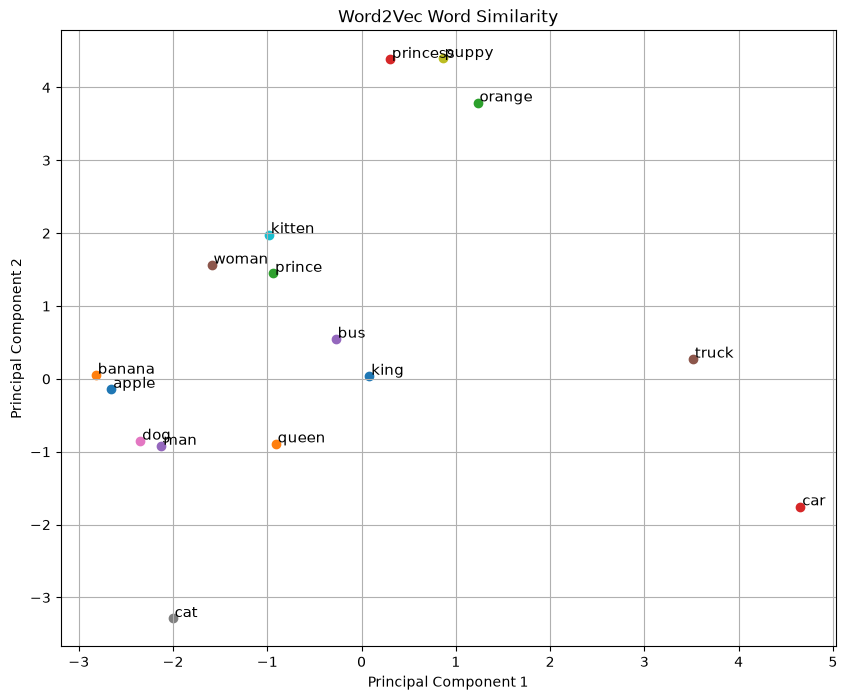

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i, word in enumerate(words):
    x = vectors_2d[i, 0]
    y = vectors_2d[i, 1]
    plt.scatter(x, y)
    plt.text(
        x + 0.02,
        y + 0.02,
        word,
        fontsize=11
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Word2Vec Word Similarity")
plt.grid(True)
plt.show()

### PCA – 주성분 분석 (Principal Component Analysis)

- 가능한 한 많은 정보를 유지하면서 특징(feature)의 수를 줄이는 기법.
- PCA는 주성분(principal component)이라 부르는 새로운 축을 찾는다.
    - PC1: 분산이 가장 큰 방향
    - PC2: 분산이 두 번째로 큰 방향
    - 주성분들은 서로 수직이다.
- 예시

    | 학생 (Student) | 수학 (Math) | 물리 (Physics) |
    |---|---|---|
    | A | 90 | 88 |
    | B | 80 | 82 |
    | C | 70 | 68 |
    | D | 60 | 62 |

PC1은 학생의 전반적인 정량적(quantitative) 능력을 나타낼 수 있다.

<p align="center"><img src="images/img-2026-09-23-10-39-30.png" width="50%"/></p>

### CBOW 모델 구현 (Implement the CBOW Model)

과제 #3 (HW#3)

- Skip-gram은 중심어로 문맥어를 예측하고, CBOW는 주변 문맥어들로 중심어를 예측한다.
- 예: `king is a royal man`에서 window=2이면 `[is, a, man] → royal`이다.
- 앞에서 만든 `corpus`, `word_to_id`, `id_to_word`, `vocab_size`, `device`를 사용한다.
- 문맥어 ID → 임베딩 → 문맥 임베딩의 평균 → 선형 레이어 → 중심어 logit 순서로 계산한다.

#### CBOW 학습 쌍과 DataLoader 생성

문장 경계에서는 문맥어 수가 줄어든다. 배치로 묶기 위해 빈 자리를 전용 패딩 ID로 채우고, 평균을 구할 때는 실제 문맥어만 센다. 문맥이 없는 단어는 학습 쌍에서 제외한다.

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def create_cbow_pairs(corpus, window=2):
    pairs = []
    for sentence in corpus:
        for i in range(len(sentence)):
            start = max(0, i - window)
            end = min(len(sentence), i + window + 1)
            context_ids = [
                word_to_id[sentence[j]]
                for j in range(start, end)
                if j != i
            ]
            if context_ids:
                center_id = word_to_id[sentence[i]]
                pairs.append((context_ids, center_id))
    return pairs

cbow_pairs = create_cbow_pairs(corpus, window=2)
print("No of CBOW training pairs:", len(cbow_pairs))
for context_ids, center_id in cbow_pairs[:5]:
    print(
        [id_to_word[idx] for idx in context_ids],
        "->", id_to_word[center_id]
    )

# 기존 어휘 ID(0 ~ vocab_size - 1)와 겹치지 않는 패딩 ID
cbow_padding_id = vocab_size
cbow_contexts = pad_sequence(
    [torch.tensor(context, dtype=torch.long)
     for context, _ in cbow_pairs],
    batch_first=True,
    padding_value=cbow_padding_id
)
cbow_centers = torch.tensor(
    [center for _, center in cbow_pairs],
    dtype=torch.long
)
cbow_dataset = TensorDataset(cbow_contexts, cbow_centers)
cbow_loader = DataLoader(
    cbow_dataset, batch_size=64, shuffle=True
)
print(cbow_contexts.shape, cbow_centers.shape)

#### CBOW 신경망 구성

- 입력 크기는 `(batch_size, 문맥 길이)`, 임베딩 크기는 `(batch_size, 문맥 길이, embedding_dim)`이다.
- `padding_idx`의 임베딩은 0으로 유지된다. 임베딩의 합을 실제 문맥어 수로 나누면 패딩을 제외한 평균이 된다.
- 출력 크기는 `(batch_size, vocab_size)`이다. 패딩은 예측 대상에 포함하지 않는다.
- `CrossEntropyLoss`에 logit을 직접 전달하므로 모델 안에서 softmax를 적용하지 않는다.

In [ ]:
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size + 1,
            embedding_dim,
            padding_idx=vocab_size
        )
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_words):
        embedded = self.embedding(context_words)
        context_counts = (
            context_words != self.embedding.padding_idx
        ).sum(dim=1, keepdim=True)
        mean_embedding = embedded.sum(dim=1) / context_counts
        logits = self.output(mean_embedding)
        return logits

cbow_model = CBOWModel(
    vocab_size, embedding_dim=50
).to(device)
print(cbow_model)

#### CBOW 학습

앞의 Skip-gram과 동일하게 Adam(lr=0.01)과 교차 엔트로피 손실을 사용하여 200 epoch 학습한다. 입력은 문맥어 묶음이고 정답은 중심어 ID이다.

In [ ]:
cbow_criterion = nn.CrossEntropyLoss()
cbow_optimizer = torch.optim.Adam(
    cbow_model.parameters(), lr=0.01
)
cbow_epochs = 200
cbow_losses = []
cbow_model.train()

for epoch in range(cbow_epochs):
    total_loss = 0
    for contexts, centers in cbow_loader:
        contexts = contexts.to(device)
        centers = centers.to(device)
        cbow_optimizer.zero_grad()
        logits = cbow_model(contexts)
        loss = cbow_criterion(logits, centers)
        loss.backward()
        cbow_optimizer.step()
        total_loss += loss.item() * centers.size(0)

    average_loss = total_loss / len(cbow_dataset)
    cbow_losses.append(average_loss)
    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}, "
            f"Loss: {average_loss:.4f}"
        )

#### 중심어 예측과 학습된 임베딩 확인

`king is a royal man`에서 `royal`의 문맥어로 중심어 후보를 확인한다. 아래 예시는 학습 데이터에 대한 확인이며, 새로운 문장에 대한 평가가 아니다. 작은 말뭉치에는 동일한 문맥에 여러 정답이 있으므로 손실이 0이 되거나 항상 한 단어만 예측되지는 않는다.

In [ ]:
cbow_model.eval()
example_context = ["is", "a", "man"]
example_ids = torch.tensor(
    [[word_to_id[word] for word in example_context]],
    dtype=torch.long,
    device=device
)
with torch.no_grad():
    probabilities = torch.softmax(cbow_model(example_ids), dim=1)
    values, indices = probabilities[0].topk(3)

print("Context:", example_context)
for score, idx in zip(values.tolist(), indices.tolist()):
    print(f"{id_to_word[idx]}: {score:.4f}")

# 패딩 행을 제외한 실제 단어의 임베딩만 추출한다.
cbow_embeddings = cbow_model.embedding.weight[:vocab_size].detach()
print("CBOW embeddings:", cbow_embeddings.shape)
for word1, word2 in [("king", "queen"), ("dog", "cat")]:
    score = F.cosine_similarity(
        cbow_embeddings[word_to_id[word1]].unsqueeze(0),
        cbow_embeddings[word_to_id[word2]].unsqueeze(0)
    )
    print(f"{word1} - {word2}: {score.item():.4f}")